In [1]:
!pip install --upgrade torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 39.4 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [3]:
import sys
import os
import torch
from google.colab import drive
from tqdm import tqdm
from transformers import AutoTokenizer
from peft import PeftModel # <--- Nuova importazione per gestire i due adattatori
import matplotlib.pyplot as plt
import cv2
import numpy as np
from PIL import Image

# Monta Drive e aggiungi src al path
drive.mount('/content/drive')
BASE_DRIVE = '/content/drive/MyDrive/DeepLearning'
SRC_DIR = os.path.join(BASE_DRIVE, 'src')
if SRC_DIR not in sys.path:
    sys.path.append(SRC_DIR)

from dataset import CLEVRDataset
from models import MultimodalCoT

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Setup completato. Device: {device}")

Mounted at /content/drive
✅ Setup completato. Device: cuda


In [4]:
from torchvision import transforms

# Usa lo stesso tokenizer del training
MODEL_NAME = "t5-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# TRASFORMAZIONE IDENTICA AL TRAINING
transform = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
print("✅ Tokenizer e Transform pronti.")

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

✅ Tokenizer e Transform pronti.


In [ ]:
from torch.utils.data import DataLoader

VAL_INDEX = os.path.join(BASE_DRIVE, 'indexes/val_index.json')
VAL_IMG_DIR = os.path.join(BASE_DRIVE, 'data/processed/images/val')

val_dataset = CLEVRDataset(
    index_path=VAL_INDEX,
    img_dir=VAL_IMG_DIR,
    tokenizer=tokenizer,
    transform=transform
)

def custom_collate_fn(batch):
    return {
        'pixel_values': torch.stack([item['pixel_values'] for item in batch]),
        'input_text': [item['input_text'] for item in batch],
        'target_text': [item['target_text'] for item in batch],
        'raw_item': [item['raw_item'] for item in batch]
    }

val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=custom_collate_fn)
print(f"✅ DataLoader pronto. Campioni di validazione: {len(val_dataset)}")

In [6]:
print("🔄 Caricamento dei moduli custom in memoria...")

# Pesi Fase 1 (Dal vecchio addestramento, salvati come dizionario unico)
stage1_custom = torch.load(os.path.join(BASE_DRIVE, 'lora_adapter_final', 'custom_modules.pth'))
stage1_proj = stage1_custom['projector']
stage1_attn = stage1_custom['cross_attention']

# Pesi Fase 2 (Dal nuovo addestramento, salvati separatamente)
stage2_proj = torch.load(os.path.join(BASE_DRIVE, 'lora_adapter_stage2', 'projector.pth'))
stage2_attn = torch.load(os.path.join(BASE_DRIVE, 'lora_adapter_stage2', 'cross_attn.pth'))

# 1. Inizializza l'architettura base
model = MultimodalCoT().to(device)

# ... (il resto della cella rimane identico) ...

print("🔗 Configurazione PEFT Multi-Adapter sul T5...")
# Inizializziamo PEFT caricando il primo adattatore
model.llm = PeftModel.from_pretrained(
    model.llm,
    os.path.join(BASE_DRIVE, 'lora_adapter_final'),
    adapter_name="stage1"
)
# Aggiungiamo il secondo adattatore allo stesso modello base
model.llm.load_adapter(
    os.path.join(BASE_DRIVE, 'lora_adapter_stage2'),
    adapter_name="stage2"
)

# Funzioni di scambio ultra-rapido
def switch_to_stage1():
    model.llm.set_adapter("stage1")
    model.projector.load_state_dict(stage1_proj)
    model.cross_attention.load_state_dict(stage1_attn)

def switch_to_stage2():
    model.llm.set_adapter("stage2")
    model.projector.load_state_dict(stage2_proj)
    model.cross_attention.load_state_dict(stage2_attn)

model.eval()
print("✅ Modello a Due Fasi pronto per l'inferenza.")

🔄 Caricamento dei moduli custom in memoria...


model.safetensors:   0%|          | 0.00/1.23G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

🔗 Configurazione PEFT Multi-Adapter sul T5...
✅ Modello a Due Fasi pronto per l'inferenza.


🔍 Analisi Cascade Reasoning e Attention Maps su 5 campioni...


CAMPIONE 1
🔹 DOMANDA:
How many other things are there of the same color as the tiny metallic thing?

🔸 RAGIONAMENTO (Fase 1):
Let's think step by step. Look at the scene. Consider the small ones. Identify the metal objects. Isolate the specific object. Process the same color. Count them.

🎯 RISPOSTA INFERITA (Fase 2): 0 | ✅ TARGET: 0

🧠 Mappa filtrata su: 'thing' (Token: ▁things)


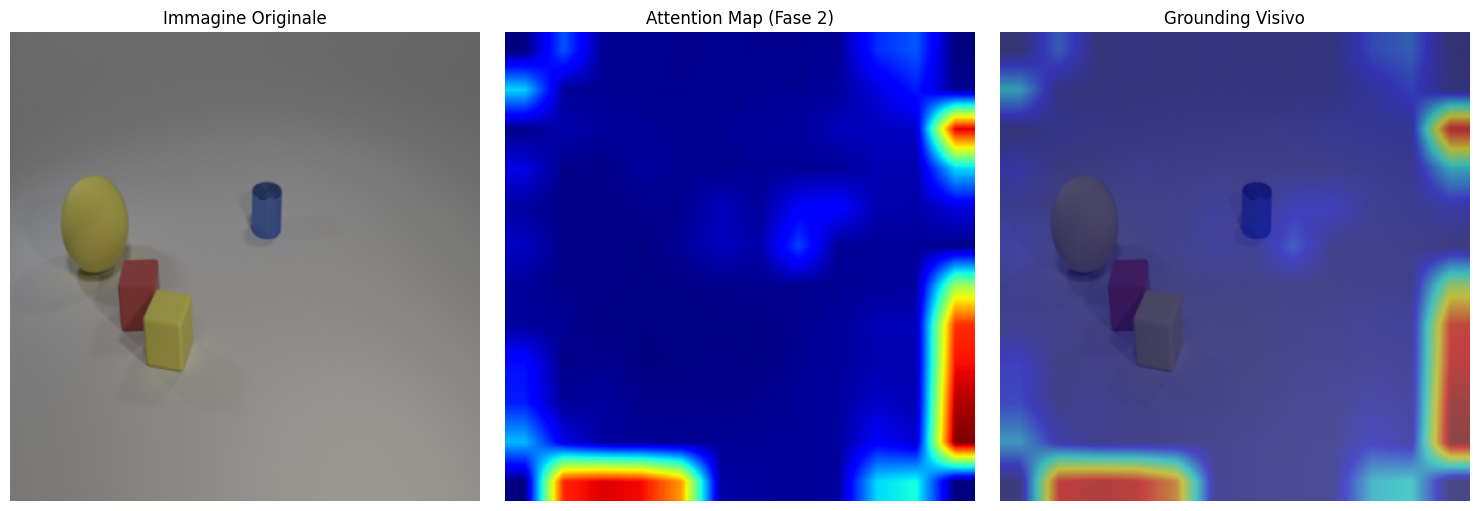


CAMPIONE 2
🔹 DOMANDA:
How big is the blue block?

🔸 RAGIONAMENTO (Fase 1):
Let's think step by step. Look at the scene. Focus on the blue objects. Select the cubes. Isolate the specific object. Identify its size.

🎯 RISPOSTA INFERITA (Fase 2): small | ✅ TARGET: small

🧠 Mappa filtrata su: 'block' (Token: ▁block)


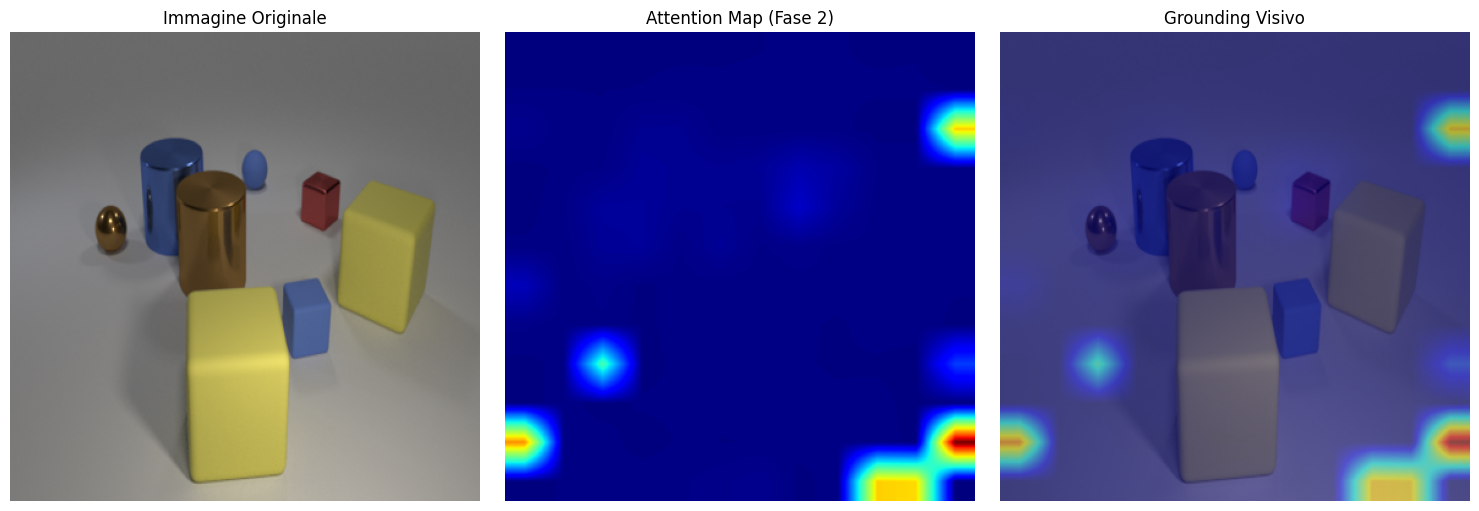


CAMPIONE 3
🔹 DOMANDA:
There is a red object right of the big brown object; what size is it?

🔸 RAGIONAMENTO (Fase 1):
Let's think step by step. Look at the scene. Consider the large ones. Focus on the brown objects. Isolate the specific object. Look at what is right the previous object. Focus on the red objects. Isolate the specific object. Identify its size.

🎯 RISPOSTA INFERITA (Fase 2): large | ✅ TARGET: large

🧠 Mappa filtrata su: 'red' (Token: ▁red)


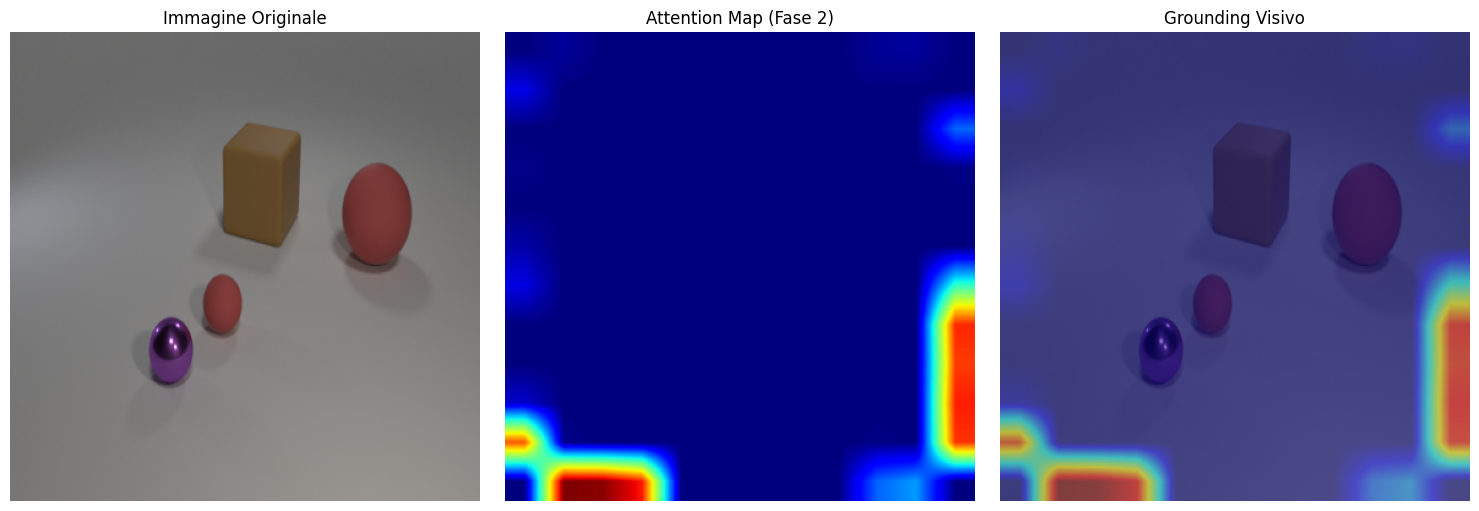


CAMPIONE 4
🔹 DOMANDA:
How many small things are either matte spheres or matte cylinders?

🔸 RAGIONAMENTO (Fase 1):
Let's think step by step. Look at the scene. Identify the rubber objects. Select the spheres. Look at the scene. Identify the rubber objects. Select the cylinders. Combine these groups. Consider the small ones. Count them.

🎯 RISPOSTA INFERITA (Fase 2): 4 | ✅ TARGET: 4

🧠 Mappa filtrata su: 'cylinder' (Token: cylinder)


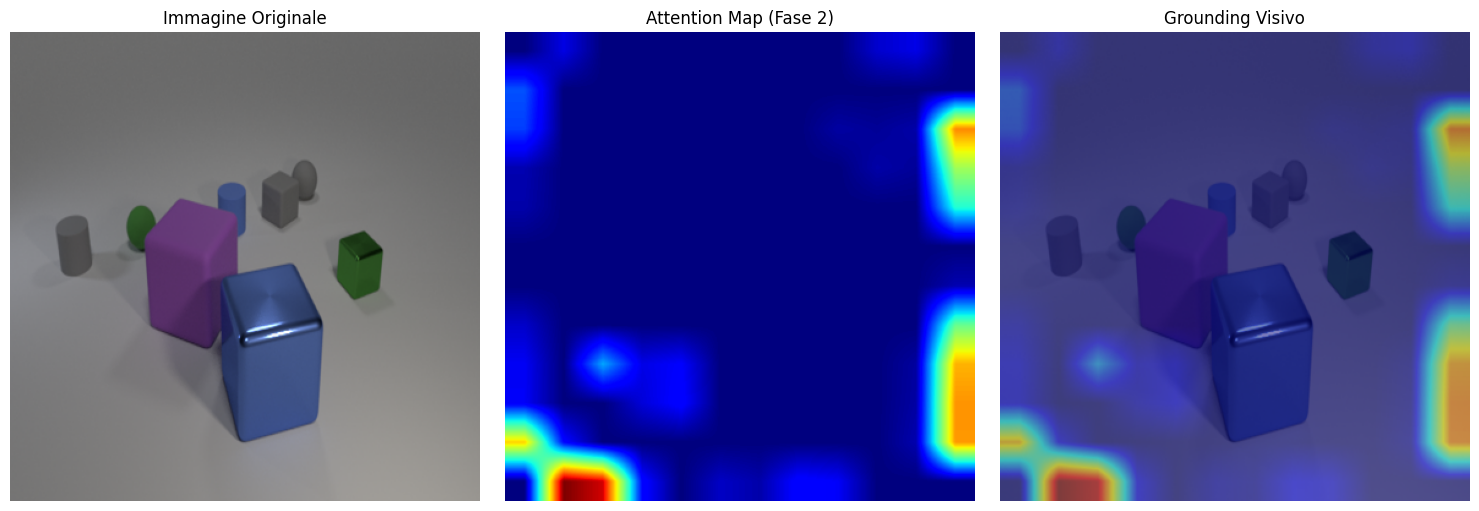


CAMPIONE 5
🔹 DOMANDA:
There is a matte thing that is in front of the gray ball; is it the same size as the gray object?

🔸 RAGIONAMENTO (Fase 1):
Let's think step by step. Look at the scene. Focus on the gray objects. Select the spheres. Isolate the specific object. Look at what is front the previous object. Identify the rubber objects. Isolate the specific object. Identify its size. Look at the scene. Focus on the gray objects. Isolate the specific object. Identify its size. Check if their size is the same.

🎯 RISPOSTA INFERITA (Fase 2): no | ✅ TARGET: no

🧠 Mappa filtrata su: 'thing' (Token: ▁thing)


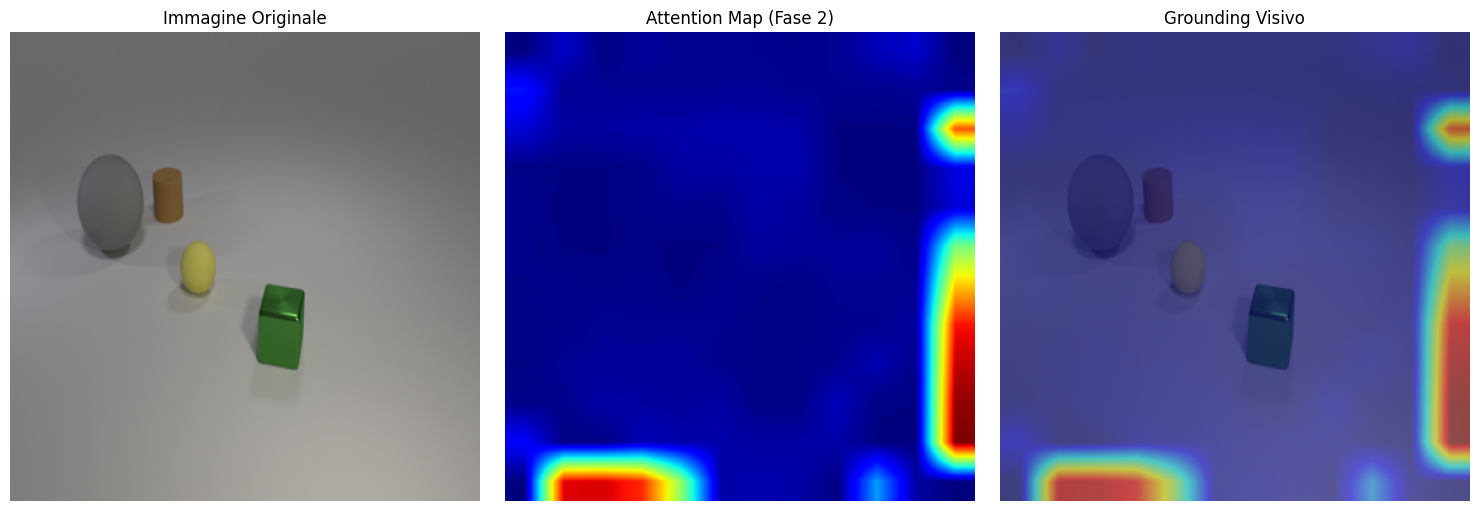

In [8]:
print("🔍 Analisi Cascade Reasoning e Attention Maps su 5 campioni...\n")

with torch.no_grad():
    batch = next(iter(val_loader))

    # Iteriamo su 5 campioni
    for i in range(5):
        # Estraiamo i dati specifici per il campione corrente
        pixel_values = batch['pixel_values'][i].unsqueeze(0).to(device)
        question_text = batch['raw_item'][i]['question']
        target_answer = batch['raw_item'][i].get('answer', 'N/A')

        # ==========================================
        # 🧠 SELEZIONE DINAMICA DELLA TARGET WORD
        # ==========================================
        # Vocabolario tipico degli oggetti/attributi visivi del dataset
        visual_concepts = [
            "cylinder", "cube", "sphere", "block", "thing",
            "rubber", "metal", "metallic", "matte",
            "red", "blue", "green", "yellow", "purple", "cyan", "gray", "brown",
            "large", "small", "tiny", "big"
        ]

        target_word = "object" # Fallback di default

        # Scansioniamo la domanda e prendiamo il primo concetto visivo che troviamo
        for concept in visual_concepts:
            if concept in question_text.lower():
                target_word = concept
                break # Trovato! Usciamo dal loop di ricerca

        # ==========================================
        # ESECUZIONE FASE 1 (Genera il Rationale)
        # ==========================================
        switch_to_stage1()
        input_s1 = f"Question: {question_text} Answer:"
        inputs_s1 = tokenizer(input_s1, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)

        generated_ids_s1, _ = model.generate(
            input_ids=inputs_s1.input_ids,
            attention_mask=inputs_s1.attention_mask,
            pixel_values=pixel_values,
            max_new_tokens=150
        )

        raw_output_s1 = tokenizer.batch_decode(generated_ids_s1, skip_special_tokens=True)[0]
        # Tronchiamo l'eventuale risposta finale allucinata dello Stage 1
        rationale = raw_output_s1.split("The final answer is:")[0].strip()

        # ==========================================
        # ESECUZIONE FASE 2 (Inferenza Risposta)
        # ==========================================
        switch_to_stage2()
        input_s2 = f"Question: {question_text} Rationale: {rationale} Answer:"
        inputs_s2 = tokenizer(input_s2, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)

        # Generiamo chiedendo max 10 token e disattivando la penalità di ripetizione
        generated_ids_s2, attn_weights_s2 = model.generate(
            input_ids=inputs_s2.input_ids,
            attention_mask=inputs_s2.attention_mask,
            pixel_values=pixel_values,
            max_new_tokens=10
        )

        final_answer = tokenizer.batch_decode(generated_ids_s2, skip_special_tokens=True)[0].strip()

        # ==========================================
        # ESTRAZIONE ATTENZIONE PULITA (STAGE 2)
        # ==========================================
        tokens = tokenizer.convert_ids_to_tokens(inputs_s2.input_ids[0])
        target_idx = -1

        for idx, token in enumerate(tokens):
            if target_word in token.lower():
                target_idx = idx
                break

        if target_idx != -1:
            patch_attn = attn_weights_s2[0][target_idx].cpu().numpy()
            target_str_info = f"'{target_word}' (Token: {tokens[target_idx]})"
        else:
            patch_attn = attn_weights_s2[0].mean(dim=0).cpu().numpy()
            target_str_info = f"Media Globale (Parola non trovata)"

        # Rimozione CLS token e Sinks
        if len(patch_attn) == 145:
            patch_attn = patch_attn[1:]

        patch_attn[0] = 0
        patch_attn[11] = 0
        patch_attn[132] = 0
        patch_attn[143] = 0

        grid_size = int(np.sqrt(len(patch_attn)))
        patch_attn = patch_attn.reshape(grid_size, grid_size)
        patch_attn = (patch_attn - patch_attn.min()) / (patch_attn.max() - patch_attn.min() + 1e-8)

        # Plotting
        heatmap = cv2.resize(patch_attn, (384, 384))
        img_path = os.path.join(BASE_DRIVE, 'data/processed/images/val', batch['raw_item'][i]['image_filename'])
        original_img = Image.open(img_path).convert('RGB').resize((384, 384))
        original_img_np = np.array(original_img)

        heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
        heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
        superimposed_img = heatmap_colored * 0.5 + original_img_np * 0.5
        superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

        # Output Testuale
        print("\n" + "="*80)
        print(f"CAMPIONE {i+1}")
        print("="*80)
        print(f"🔹 DOMANDA:\n{question_text}")
        print(f"\n🔸 RAGIONAMENTO (Fase 1):\n{rationale}")
        print(f"\n🎯 RISPOSTA INFERITA (Fase 2): {final_answer} | ✅ TARGET: {target_answer}")
        print(f"\n🧠 Mappa filtrata su: {target_str_info}")

        # Output Visivo
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(original_img)
        axes[0].set_title("Immagine Originale", fontsize=12)
        axes[0].axis('off')

        axes[1].imshow(heatmap, cmap='jet')
        axes[1].set_title(f"Attention Map (Fase 2)", fontsize=12)
        axes[1].axis('off')

        axes[2].imshow(superimposed_img)
        axes[2].set_title("Grounding Visivo", fontsize=12)
        axes[2].axis('off')

        plt.tight_layout()
        plt.show()